# Running inference to produce predictions


This notebook goes through plotting a prediction from a trained model, and gathering all the predictions to compare z_spec and z_phot

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.visualization import make_lupton_rgb
import numpy as np
import pandas as pd
from astropy.nddata import Cutout2D
from astropy.wcs import WCS

import cv2
from detectron2.structures import BoxMode
from astropy.table import Table
import glob
from astropy.coordinates import SkyCoord  # High-level coordinates
from detectron2.config import LazyConfig, get_cfg, instantiate
import os
import scipy.stats as stats
import h5py
import json
import astropy.units as u
from astropy.coordinates import SkyCoord

import warnings
import time

from astropy.wcs import FITSFixedWarning
warnings.filterwarnings("ignore", category=FITSFixedWarning)
import torch
import torch.nn.functional as F
from detectron2.data import detection_utils as utils
import pickle
from sklearn.utils import resample
from matplotlib import gridspec


In [2]:
cfgfile = '/home/g4merz/DP1/configs/solo/solo_mvitv2_dp1.py'

output_dir = "/home/g4merz/DP1/models/"
run_name = "IMpre_MViTv2_DP1_nomask"


In [3]:
with h5py.File('/home/g4merz/DP1/dp1_matched_v4_test.hdf5','r') as f:
    redshifts = f['redshift'][:]
    ras = f['coord_ra'][:]
    decs = f['coord_dec'][:]
    objectIds = f['objectId'][:]
    print(f.keys())
    imag= f['i_cModelMag'][:]
    
testcat = pd.DataFrame({'redshift':redshifts,'ra':ras,'dec':decs,'objectId':objectIds})
testcoords = SkyCoord(ra=ras,dec=decs,unit=u.deg)


<KeysViewHDF5 ['confidence', 'coord_dec', 'coord_ra', 'ebv', 'euclid_h_unifMag', 'euclid_h_unifMagErr', 'euclid_j_unifMag', 'euclid_j_unifMagErr', 'euclid_vis_psfMag', 'euclid_vis_psfMagErr', 'euclid_y_unifMag', 'euclid_y_unifMagErr', 'ext_class', 'g_cModelMag', 'g_cModelMagErr', 'g_gaap1p0Mag', 'g_gaap1p0MagErr', 'g_gaap3p0Mag', 'g_gaap3p0MagErr', 'g_kronMag', 'g_kronMagErr', 'g_psfMag', 'g_psfMagErr', 'g_sersicMag', 'g_sersicMagErr', 'i_cModelMag', 'i_cModelMagErr', 'i_gaap1p0Mag', 'i_gaap1p0MagErr', 'i_gaap3p0Mag', 'i_gaap3p0MagErr', 'i_kronMag', 'i_kronMagErr', 'i_psfMag', 'i_psfMagErr', 'i_sersicMag', 'i_sersicMagErr', 'objectId', 'r_cModelMag', 'r_cModelMagErr', 'r_gaap1p0Mag', 'r_gaap1p0MagErr', 'r_gaap3p0Mag', 'r_gaap3p0MagErr', 'r_kronMag', 'r_kronMagErr', 'r_psfMag', 'r_psfMagErr', 'r_sersicMag', 'r_sersicMagErr', 'redshift', 'refExtendedness', 'snr_i_cModel', 'snr_i_gaap1p0', 'u_cModelMag', 'u_cModelMagErr', 'u_gaap1p0Mag', 'u_gaap1p0MagErr', 'u_gaap3p0Mag', 'u_gaap3p0MagErr

In [6]:
with open('/home/g4merz/DP1/processed_data/test_dicts_new.json') as f:
    test_ddicts = json.load(f)

In [22]:
with open('/home/g4merz/DP1/test_wcs_dict.json') as f:
    test_wcs_ddicts = json.load(f)

In [18]:
with open('/home/g4merz/DP1/processed_data/train_dicts_new.json') as f:
    train_ddicts = json.load(f)

In [29]:
imgind = int(test_ddicts[100]['filename'].split('/')[-1].split('.npy')[0][4:])
imgind

1088

In [5]:
oids = []
zs=[]
for d in test_ddicts:
    for a in d['annotations']:
        if a['redshift'] !=-1:
            oids.append(a['id'])
            zs.append(a['redshift'])

In [ ]:
oidstrain = []
zstrain=[]
for d in train_ddicts:
    for a in d['annotations']:
        if a['redshift'] !=-1:
            oidstrain.append(a['id'])
            zstrain.append(a['redshift'])

In [7]:
dztest = pd.DataFrame({'object_id':np.array(oids), 'z':np.array(zs)})
dztrain = pd.DataFrame({'object_id':np.array(oidstrain), 'z':np.array(zstrain)})

In [8]:
dmerge = pd.merge(dcat,dztest,on='object_id',how='left')
dmergetrain = pd.merge(dcat,dztrain,on='object_id',how='left')

dspecz_test = dcat.set_index('object_id').loc[oids].reset_index()


### Plot training loss curves

In [4]:
def smooth_loss(losses, weight: float):  # Weight between 0 and 1
    last = losses[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in losses:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor the last smoothed value
        
    return smoothed


    

In [5]:
def get_losses(run_name,lossdir='/home/g4merz/JWST/models/kfold/'):
    with open(os.path.join(lossdir,f'{run_name}_losses.json'), 'r') as jsonfile:
        losses = json.load(jsonfile)
    #with open(os.path.join(lossdir,f'{run_name}_val_losses.json'), 'r') as jsonfile:
    #    val_losses = json.load(jsonfile)


    total_losses = []
    ztrain_losses = []

    for key, eloss in losses.items():
        total_losses.append(sum([val for key, val in eloss.items()]))
        ztrain_losses.append(eloss['redshift_loss'])
    total_losses = np.array(total_losses)


    #total_val_losses = []
    #zval_losses = []
    #for key, eloss in val_losses.items():
    #    total_val_losses.append(sum([val for key, val in eloss.items()]))
    #    zval_losses.append(eloss['redshift_loss'])

    #total_val_losses = np.array(total_val_losses)
    
    return total_losses, ztrain_losses#, total_val_losses, zval_losses



def plot_single_loss(tl,ztl,epochs=150,ipb=106):
    fig, ax = plt.subplots(figsize=(7,6))
    iters = np.arange(0.5,epochs+0.5,0.5)*ipb
    xticks = np.linspace(0,epochs,11)*ipb+1

    stl = smooth_loss(tl,0.9)
    sztl = smooth_loss(ztl,0.9)
    #stvl = smooth_loss(tvl,0.9)
    #szvl = smooth_loss(zvl,0.9)

    #plt.plot(total_losses,alpha=0.3, color='lightskyblue')
    #plt.plot(sl,label='total (training)',color='lightskyblue')

    #plt.plot(tl,alpha=0.3, color='lightskyblue')
    plt.plot(stl, label='total (training)',color='lightskyblue')
    plt.plot(sztl,label='redshift (training)',color='royalblue')

    #plt.plot(iters[1::2],stvl,label='total (validation)',color='lightcoral')
    #plt.plot(iters[1::2],szvl,label='redshift (validation)',color='darkred')

    #plt.fill_between(np.arange(len(sl)),-np.std(sls,axis=0)+sl,np.std(sls,axis=0)+sl,label='total (training)',alpha=0.3)

    #plt.plot(iters[1::2],total_val_losses_av, color='maroon', label='total (validation)')
    #plt.plot(iters[1::2],vsl,color='C1')

    plt.tick_params(axis='both', which='major', labelsize=15)


    #plt.xticks(xticks, labels=[int(l) for l in np.linspace(0,epochs,11)]);
    plt.xticks(xticks, labels=[int(l) for l in np.linspace(0,epochs,11)]);

    plt.ylabel('Loss',fontsize=16)
    plt.xlabel('Epochs',fontsize=16)
    plt.legend(loc=0)
    #plt.savefig('/home/g4merz/JWST/plots/by_area/GMLpre_R50_0.7_loss.png')
    
    return fig,ax
    
    
def plot_single_likelihood(tl,ztl,tvl,zvl,epochs=150,ipb=106):
    fig, ax = plt.subplots(figsize=(7,6))

    stl = smooth_loss(tl,0.9)
    sztl = smooth_loss(ztl,0.9)
    stvl = smooth_loss(tvl,0.9)
    szvl = smooth_loss(zvl,0.9)
    
    iters = np.arange(0.5,epochs+0.5,0.5)*ipb
    xticks = np.linspace(0,epochs,11)*ipb+1

    
    plt.plot(np.exp(-np.array(ztl)),color='lightskyblue',alpha=0.3)
    plt.plot(iters[1::2],np.exp(-np.array(zvl)),color='lightcoral')
    
    plt.plot(np.exp(-np.array(sztl)),color='royalblue')
    plt.plot(iters[1::2],np.exp(-np.array(szvl)),color='crimson')
    plt.legend(loc=0)
    plt.xlabel('Epoch',fontsize=16)
    plt.ylabel('Redshift Likelihood',fontsize=16)
    plt.xticks(xticks, labels=[int(l) for l in np.linspace(0,epochs,11)]);
    plt.tick_params(axis='both', which='major', labelsize=15)

    return fig,ax


Text(0.1, 0.9, 'IMpre ')

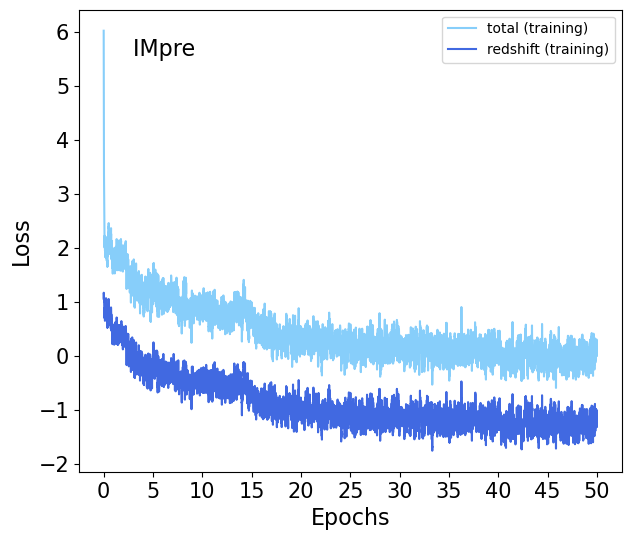

In [15]:
run_name = f'IMpre_MViTv2_DP1'
tl, ztl = get_losses(run_name,lossdir='/home/g4merz/DP1/models/')
fig,ax = plot_single_loss(tl, ztl, epochs=50,ipb=423)
plt.text(0.1, 0.9, 'IMpre ',  transform = ax.transAxes, fontsize=16)
#plt.ylim(-0.5,7)

#plt.savefig(f'/home/g4merz/HSC/plots/{run_name}_loss_curve.png')

### Load in the trained model

In [17]:
import deepdisc.model.models as roiheads
import deepdisc.model.loaders as loaders

#from deepdisc.data_format.image_readers import DC2ImageReader
from deepdisc.inference.predictors import AstroPredictor

cfg = LazyConfig.load(cfgfile)

cfg.train.init_checkpoint = os.path.join(output_dir, run_name + ".pth")

cfg.TEST.DETECTIONS_PER_IMAGE = 3000
cfg.model.proposal_generator.anchor_generator.sizes = [[8], [16], [32], [64], [128]]
cfg.model.roi_heads.batch_size_per_image=1024
#cfg.model.roi_heads._target_ = roiheads.RedshiftPDFCasROIHeadsJWST
cfg.model.roi_heads.output_features = False
#cfg.model.roi_heads.coarse_bins = np.linspace(0,3,300)
#cfg.model.backbone.bottom_up.in_chans=8



#cfg.model.proposal_generator.pre_nms_topk=[1000,500]
#cfg.model.proposal_generator.post_nms_topk=[10000,10000]
cfg.model.proposal_generator.post_nms_topk=[6000,3000]

#cfg.model.roi_heads.mask_in_features=None

cfg.model.proposal_generator.batch_size_per_image = 1024
for box_predictor in cfg.model.roi_heads.box_predictors:
    box_predictor.test_topk_per_image = 3000
    box_predictor.test_score_thresh = 0.5
    box_predictor.test_nms_thresh = 0.3
    
    
#cfg.model.backbone.square_pad = 1400


#cfg.model.pixel_mean =[0]*9
#cfg.model.pixel_std = [1]*9




In [18]:
predictor = AstroPredictor(cfg)


[08/05 16:37:08 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /home/g4merz/DP1/models/IMpre_MViTv2_DP1.pth ...


In [4]:
from detectron2.data import MetadataCatalog, DatasetCatalog
from matplotlib import colors

if "astro_test" in MetadataCatalog.list():
    print('removing astro_test')
    #DatasetCatalog.remove("astro_test")
    MetadataCatalog.remove("astro_test")

red = np.array(colors.to_rgb('red'))*255
white = np.array(colors.to_rgb('white'))*255
blue = np.array(colors.to_rgb('blue'))*255
green = np.array(colors.to_rgb('green'))*255

astrotest_metadata = MetadataCatalog.get("astro_test").set(thing_classes=["star","galaxy","bad_fit"]).set(thing_colors=[red,green,white])


In [20]:

def matched_catalog(dall, outputs, wcs):
    #dgold = dall[dall['mag_i']<=25.3]
    #ra_all = dall['ra'][:].values
    #dec_all = dall['dec'][:].values
    allcatalog = SkyCoord(ra=dall['RA'].values*u.degree, dec=dall['DEC'].values*u.degree)
        
    centers = outputs['instances'].pred_boxes.get_centers().cpu().numpy()
    c = wcs.pixel_to_world(centers[:,0],centers[:,1])

    #avoid duplicate matches by having allcatalog first
    idx, d2d, d3d = allcatalog.match_to_catalog_sky(c)
    minds = np.where(d2d.to(u.arcsec).value<=0.5)[0]

    #return dall.iloc[idx[minds]], minds
    
    return dall.iloc[minds], idx[minds]

    
from deepdisc.inference.match_objects import get_matched_object_inds



In [21]:
def get_outputs_withwcs(predictor, d, image):
    #d = metadata[i]
    wcs = d['wcs']
    with torch.no_grad():  # https://github.com/sphinx-doc/sphinx/issues/4258
        # Apply pre-processing to image.
        # image = self.aug.get_transform(original_image).apply_image(original_image)
        image = torch.as_tensor(image.astype("float32"))
        inputs = {'image':image, 'wcs':wcs, 'height':image.shape[1], 'width':image.shape[2]}

        out = predictor.model([inputs])

    return out


def get_outputs_withwcs_fixed(predictor, d, image):
    wcs = d['wcs']
    imgind = int(d['filename'].split('/')[-1].split('.npy')[0][4:])
    
    instances = utils.annotations_to_instances(d['annotations'], image.shape[1:])
    instances.pred_boxes = instances.gt_boxes
    instances.pred_classes = instances.gt_classes
    instances.gt_id = torch.tensor([a["objectId"] for a in d['annotations']])
    instances.gt_redshift = torch.tensor([a["redshift"] for a in d['annotations']])
    
    
    with torch.no_grad():  # https://github.com/sphinx-doc/sphinx/issues/4258
        # Apply pre-processing to image.
        # image = self.aug.get_transform(original_image).apply_image(original_image)
        image = torch.as_tensor(image.astype("float32"))
        #inputs = {'image':image, 'wcs':wcs, 'height':image.shape[1], 'width':image.shape[2]}
        inputs = {'image':image, 'wcs':wcs, 'height':image.shape[1], 'width':image.shape[2], 'annotations':d['annotations'], 'img_index':imgind}

        #out = predictor.model([inputs])
        out = predictor.model.inference([inputs],[instances])


    return out



### Plot predictions

There may be cases where no predictions are produced.  This could be fixed by altering the detection sensitivty of the model (test_score_thresh parameters).  However, you can also just turn off the detection aspect and force the model to produce a prediction at a given location.  I call this "forced photometry mode"

0.24579477310180664 seconds
Setting colors
detected instances: 0



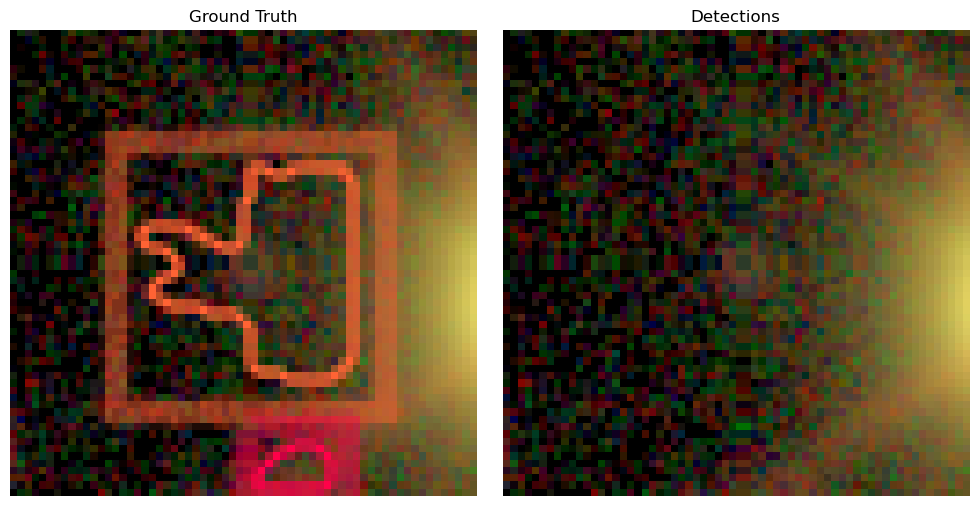

In [64]:
import matplotlib.pyplot as plt
from deepdisc.astrodet.visualizer import Visualizer
from deepdisc.astrodet.visualizer import ColorMode
from detectron2 import structures

from astropy.visualization import make_lupton_rgb

q=2656

#i=41


#di={}
#di['wcs'] = test_ddicts[q]
d = test_ddicts[q]
#wcsi = WCS(d['wcs'])
#fn = d["filename"]
imgind = int(d['filename'].split('/')[-1].split('.npy')[0][4:])
filename = f"test_v4_cutouts_{imgind}.npy"
dirpath = "/home/g4merz/DP1/processed_data/"
fn = os.path.join(dirpath, filename)
image = np.load(fn)

#imid = d['image_id']
#image = np.load(f'/home/shared/hsc/JWST/processed_data/tile20_test/image_{imid}.npy')    

img = make_lupton_rgb(image[3], image[2], image[1], stretch=15, Q=10)

#print("total instances:", len(d["annotations"]))
v0 = Visualizer(
    img,
    metadata=astrotest_metadata,
    scale=1,
    instance_mode=ColorMode.SEGMENTATION,  # remove the colors of unsegmented pixels. This option is only available for segmentation models
)
groundTruth = v0.draw_dataset_dict(d, lf=False, alpha=0.01)

#plt.figure(figsize=(12,6))

fig,ax = plt.subplots(1,2,figsize=(10,5),sharey=True)
#ax0 = plt.subplot(1, 2, 1)
ax0 = ax[0]

ax0.imshow(groundTruth.get_image())
#ax0.imshow(img)
ax0.axis("off")
ax0.set_title('Ground Truth')


image_reshape = np.transpose(image,axes=(1,2,0))

t0 = time.time()
outputs = get_outputs_withwcs(predictor,d,image)[0]
#outputs = get_outputs_withwcs_fixed(predictor,d,image)[0]
#outputs = get_outputs_withwcs(predictor,test_metadata,image,i)[0]
print(time.time()-t0, 'seconds')


v1 = Visualizer(
        img,
        metadata=astrotest_metadata,
        scale=1,
        instance_mode=ColorMode.SEGMENTATION,  # remove the colors of unsegmented pixels. This option is only available for segmentation models
    )


out = v1.draw_instance_predictions(outputs["instances"].to("cpu"),lf=False,ls='-',alpha=0.1,boxf=True, custom_labels=np.arange(len(outputs['instances'])))
print("detected instances:", len(outputs["instances"].pred_boxes))
print("")


#ax1 = plt.subplot(1, 2, 2)
ax1 = ax[1]

ax1.imshow(out.get_image())
ax1.axis("off")
ax1.set_title('Detections')

plt.tight_layout()


In [67]:
zgrid = np.linspace(0,11,1100)

dm,m = iou_matched_catalog(d,outputs)


dm_iou,m_iou = iou_matched_catalog(d,outputs)
zts = dm_iou['z'].values


In [91]:
gmm = outputs['instances'].pred_gmm.cpu()
ws = gmm[..., :5]
ws = F.softmax(ws, dim=-1).numpy()
mus = gmm[..., 5:10]
stds = torch.exp(gmm[..., 10:])


xs = np.linspace(0, 11, 1101)
ys = np.zeros_like(xs)
pdfs = []
ys = np.zeros_like(xs)
c=0
for i in range(5):
    ys += stats.norm.pdf(xs, loc=mus[c].squeeze()[i], scale=stds[c].squeeze()[i]) * ws[c].squeeze()[i]
pdfs.append(ys)
    


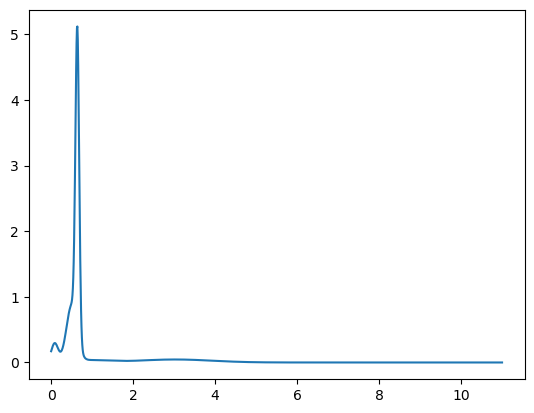

In [93]:
plt.plot(xs,pdfs[0])

In [27]:
#Get all bounding box centers in RA, DEC and then match to test catalog - confirm the center object is detected
centers = outputs['instances'].pred_boxes.get_centers().cpu().numpy()
wcsi = WCS(d['wcs'])
xs = [center[0] for center in centers]
ys = [center[1] for center in centers]
tc = wcsi.pixel_to_world(xs,ys)

In [28]:
idx, d2d, d3d = tc.match_to_catalog_sky(testcoords)

(array([10, 10, 10, 10, 10, 10, 10]), 10)

In [29]:
matches = np.where(idx==imgind)[0]
dm = d2d[matches]
dist = dm[dm.value.argmin()].to(u.arcsecond).value


0.022546298681750735

In [34]:
scores = outputs['instances'].scores.cpu().numpy()

centers = outputs['instances'].pred_boxes.get_centers().cpu().numpy()
xs = [center[0] for center in centers]
ys = [center[1] for center in centers]
tc = wcsi.pixel_to_world(xs,ys)


idx, d2d, d3d = tc.match_to_catalog_sky(testcoords)    
if imgind not in idx:
    print('No matched detection for image ', imgind)
    #nondect_inds.append(d['img_index'])

matches = np.where(idx==imgind)[0]
dm = d2d[matches]
dist = dm[dm.value.argmin()].to(u.arcsecond).value
if dist>1:
    print('No matched detection <1 arcsec for image ', imgind)
    print(idx,d2d.to(u.arcsecond).value,d['img_index'])

In [5]:

import qp
import scipy.stats as stats
import math
import seaborn as sns
from scipy.stats import sigmaclip
from astropy.stats import biweight_location, biweight_scale


def get_res(filename):
    with open(filename, 'rb') as fp:
        data = pickle.load(fp)
    return [data[key] for key in data.keys()]
    


In [6]:


def make_2d_hist_plot(
    truth: np.ndarray,
    pointEstimate: np.ndarray,
    z_min: float,
    z_max:float,
    n_zbins: int,
    nclip: int,
    abs_outlier_thresh: float,
    
):
    figure, axes = plt.subplots(figsize=(7, 6))
    bin_edges = np.linspace(
        z_min, z_max, n_zbins + 1
    )
    dz = (pointEstimate - truth) / (1 + truth)
    mean, _mean_err, std, outlier_rate, abs_outlier_rate = (
        get_biweight_mean_sigma_outlier(dz, nclip, abs_outlier_thresh)
    )
    mean, std, outlier_rate, abs_outlier_rate = (
        round(mean, 4),
        round(std, 4),
        round(outlier_rate, 4),
        round(abs_outlier_rate, 4),
    )
    h = axes.hist2d(
        truth,
        pointEstimate,
        bins=(bin_edges, bin_edges),
        norm=colors.LogNorm(),
        cmap="gray",
    )
    axes.plot(
        [z_min - 10, z_max + 10],
        [z_min - 10, z_max + 10],
        "--",
        color="red",
    )
    axes.plot(
        [z_min - 10, z_max + 10],
        [z_min - 10 - 3 * std, z_max + 10 - 3 * std],
        "--",
        color="red",
    )
    axes.plot(
        [z_min - 10, z_max + 10],
        [z_min - 10 + 3 * std, z_max + 10 + 3 * std],
        "--",
        color="red",
    )
    axes.plot(
        [],
        [],
        ".",
        alpha=0.0,
        label=rf"$\Delta z = {mean} $"
        + "\n"
        + rf"$\sigma z = {std} $"
        + "\n"
        + rf"outlier rate (>3$\sigma$) = {outlier_rate}"
        + "\n"
        + f"outlier rate (>{abs_outlier_thresh}) = {abs_outlier_rate}",
    )

    plt.xlabel("True Redshift")
    plt.ylabel("Estimated Redshift")
    cb = figure.colorbar(h[3], ax=axes)
    cb.set_label("Density")

    plt.legend()

    #plot_name = self._make_full_plot_name(prefix, "")

    return h

def get_biweight_mean_sigma_outlier(
    subset: np.ndarray, nclip: int = 3, abs_out_thresh: float = 0.2
) -> tuple[float, float, float, float, float]:
    subset_clip, _, _ = sigmaclip(subset, low=3, high=3)
    for _j in range(nclip):
        subset_clip, _, _ = sigmaclip(subset_clip, low=3, high=3)

    mean = biweight_location(subset_clip)
    std = biweight_scale(subset_clip)
    outlier_rate = np.sum(np.abs(subset) > 3 * biweight_scale(subset_clip)) / len(
        subset
    )
    abs_outlier_rate = np.sum(np.abs(subset) > abs_out_thresh) / len(
        subset
    )

    return (
        mean,
        std / np.sqrt(len(subset_clip)),
        std,
        outlier_rate,
        abs_outlier_rate,
    )

In [11]:
run_name = "IMpre_MViTv2_DP1"
#run_name = "GMLpre_R50_DP1"

outdir ='/home/g4merz/DP1/estimation/'
fnphot_test = os.path.join(outdir,f'{run_name}_test_center_outs.npy')

zps, zts, ids, scores, gmms = get_res(fnphot_test)
#pdfs_phot_test = get_pdfs(gmms,zgrid)
#pdfs_phot_test = np.array(pdfs_phot_test)
#zps_phot_test = np.array([zgrid[pdf.argmax()] for pdf in pdfs_phot_test])


missed_inds = np.load(f'/home/g4merz/DP1/estimation/{run_name}_nondect_inds.npy')
fnphot_forced = os.path.join(outdir,f'{run_name}_test_center_fixed_outs.npy')

zpsf, ztsf, idsf, gmmsf = get_res(fnphot_forced)

missed_ids = objectIds[missed_inds]
addinds = np.nonzero(np.in1d(idsf,missed_ids))[0]
zps_tot = np.hstack((zps,zpsf[addinds]))
zts_tot = np.hstack((zts,ztsf[addinds]))
ids_tot = np.hstack((ids,idsf[addinds]))
#gmms_tot = np.hstack((gmms,gmmsf[addinds]))

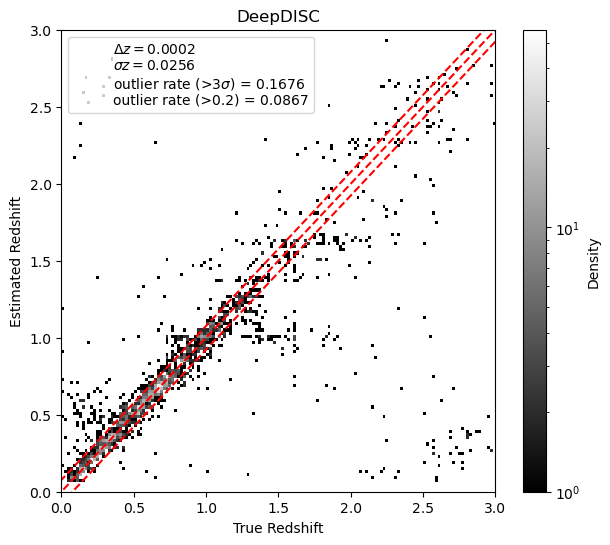

In [14]:
h = make_2d_hist_plot(
    zts_tot,
    zps_tot,
    z_min=0,
    z_max=3,
    n_zbins=150,
    nclip=3,
    abs_outlier_thresh=0.2
)
plt.title('DeepDISC')

plt.savefig('plots/IMpre_MViTv2.png')